In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [46]:
df = pd.read_csv('data/Physical_Activity_Monitoring_unlabeled.csv')
print(f"Размер данных: {df.shape}")
df.head()

Размер данных: (534601, 53)


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [49]:
print(f"Пропуски до обработки: {df.isnull().sum().sum()}")

feature_cols = [col for col in df.columns if col not in ['timestamp', 'subject_id']]
X = df[feature_cols].copy()

for col in feature_cols:
    X[col] = X[col].fillna(X[col].median())

print(f"Пропуски после обработки: {X.isnull().sum().sum()}")
print(f"Размер данных: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")

Пропуски до обработки: 125732
Пропуски после обработки: 0
Размер данных: (534601, 51)
Количество признаков: 51


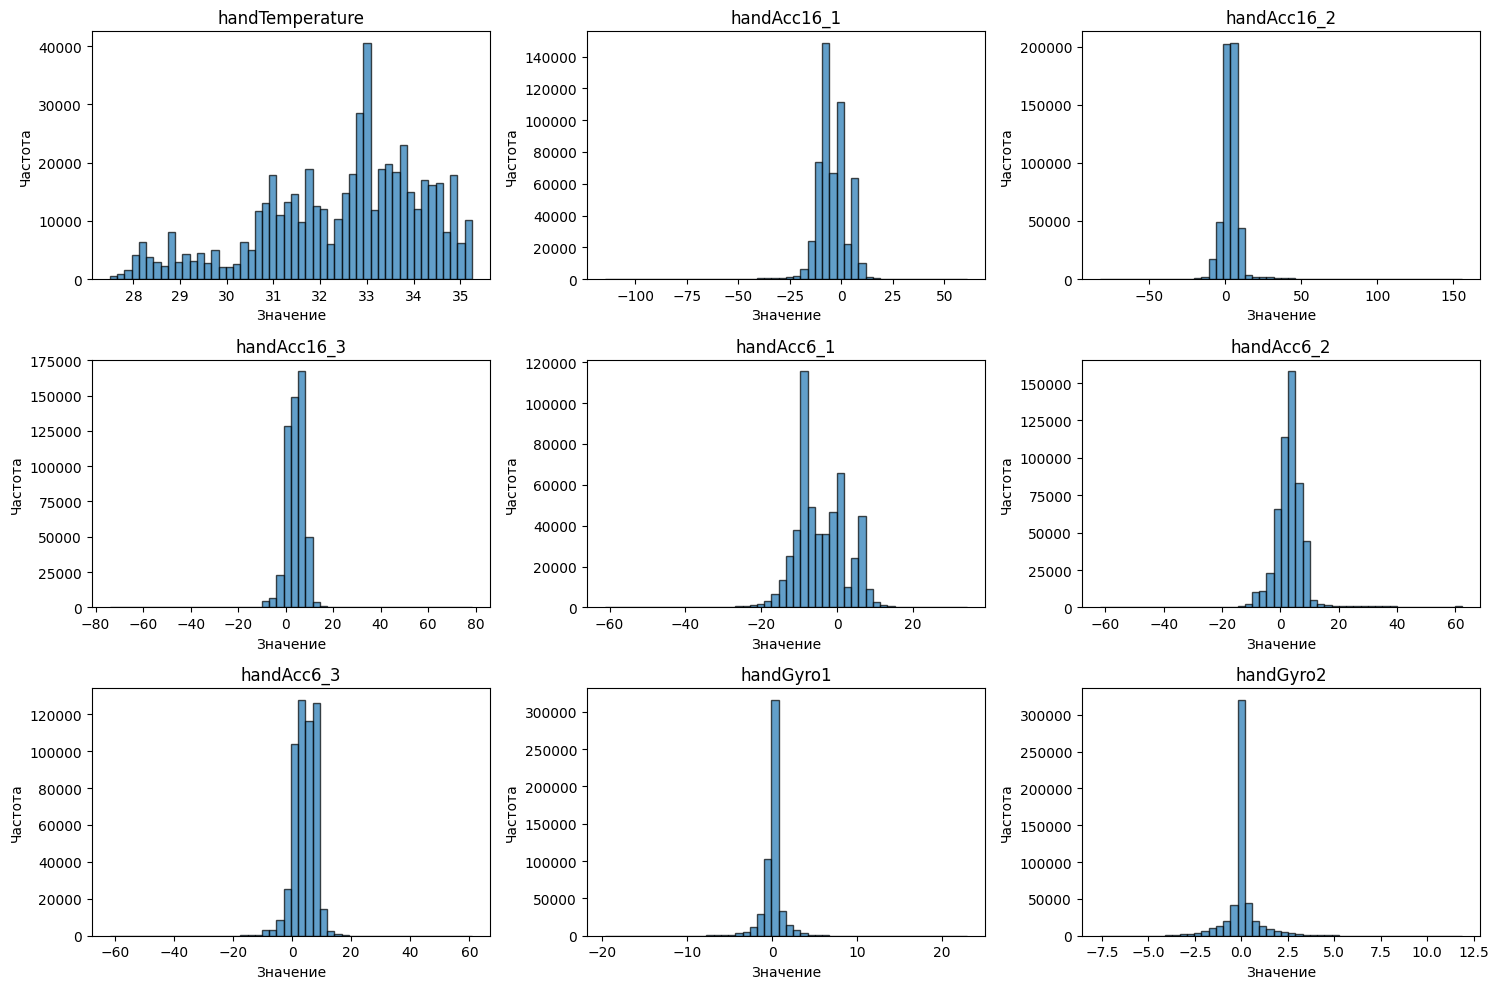

In [50]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(X.columns[:9]):
    axes[i].hist(X[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
plt.tight_layout()
plt.show()

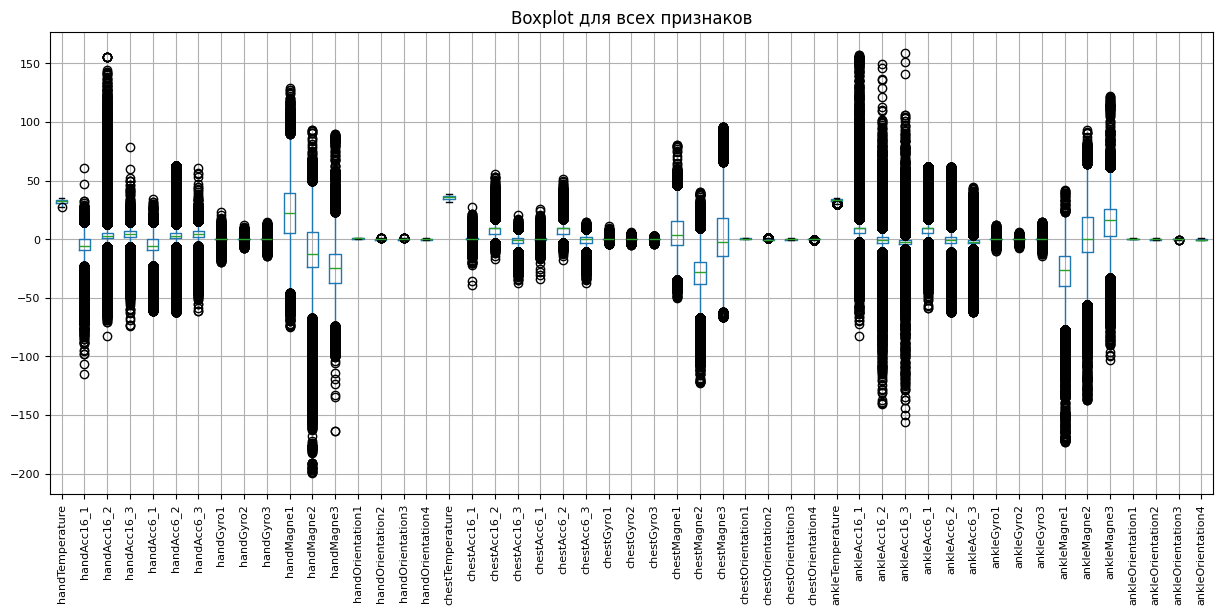

In [51]:
plt.figure(figsize=(15, 6))
X.boxplot(rot=90, fontsize=8)
plt.title('Boxplot для всех признаков')
plt.show()

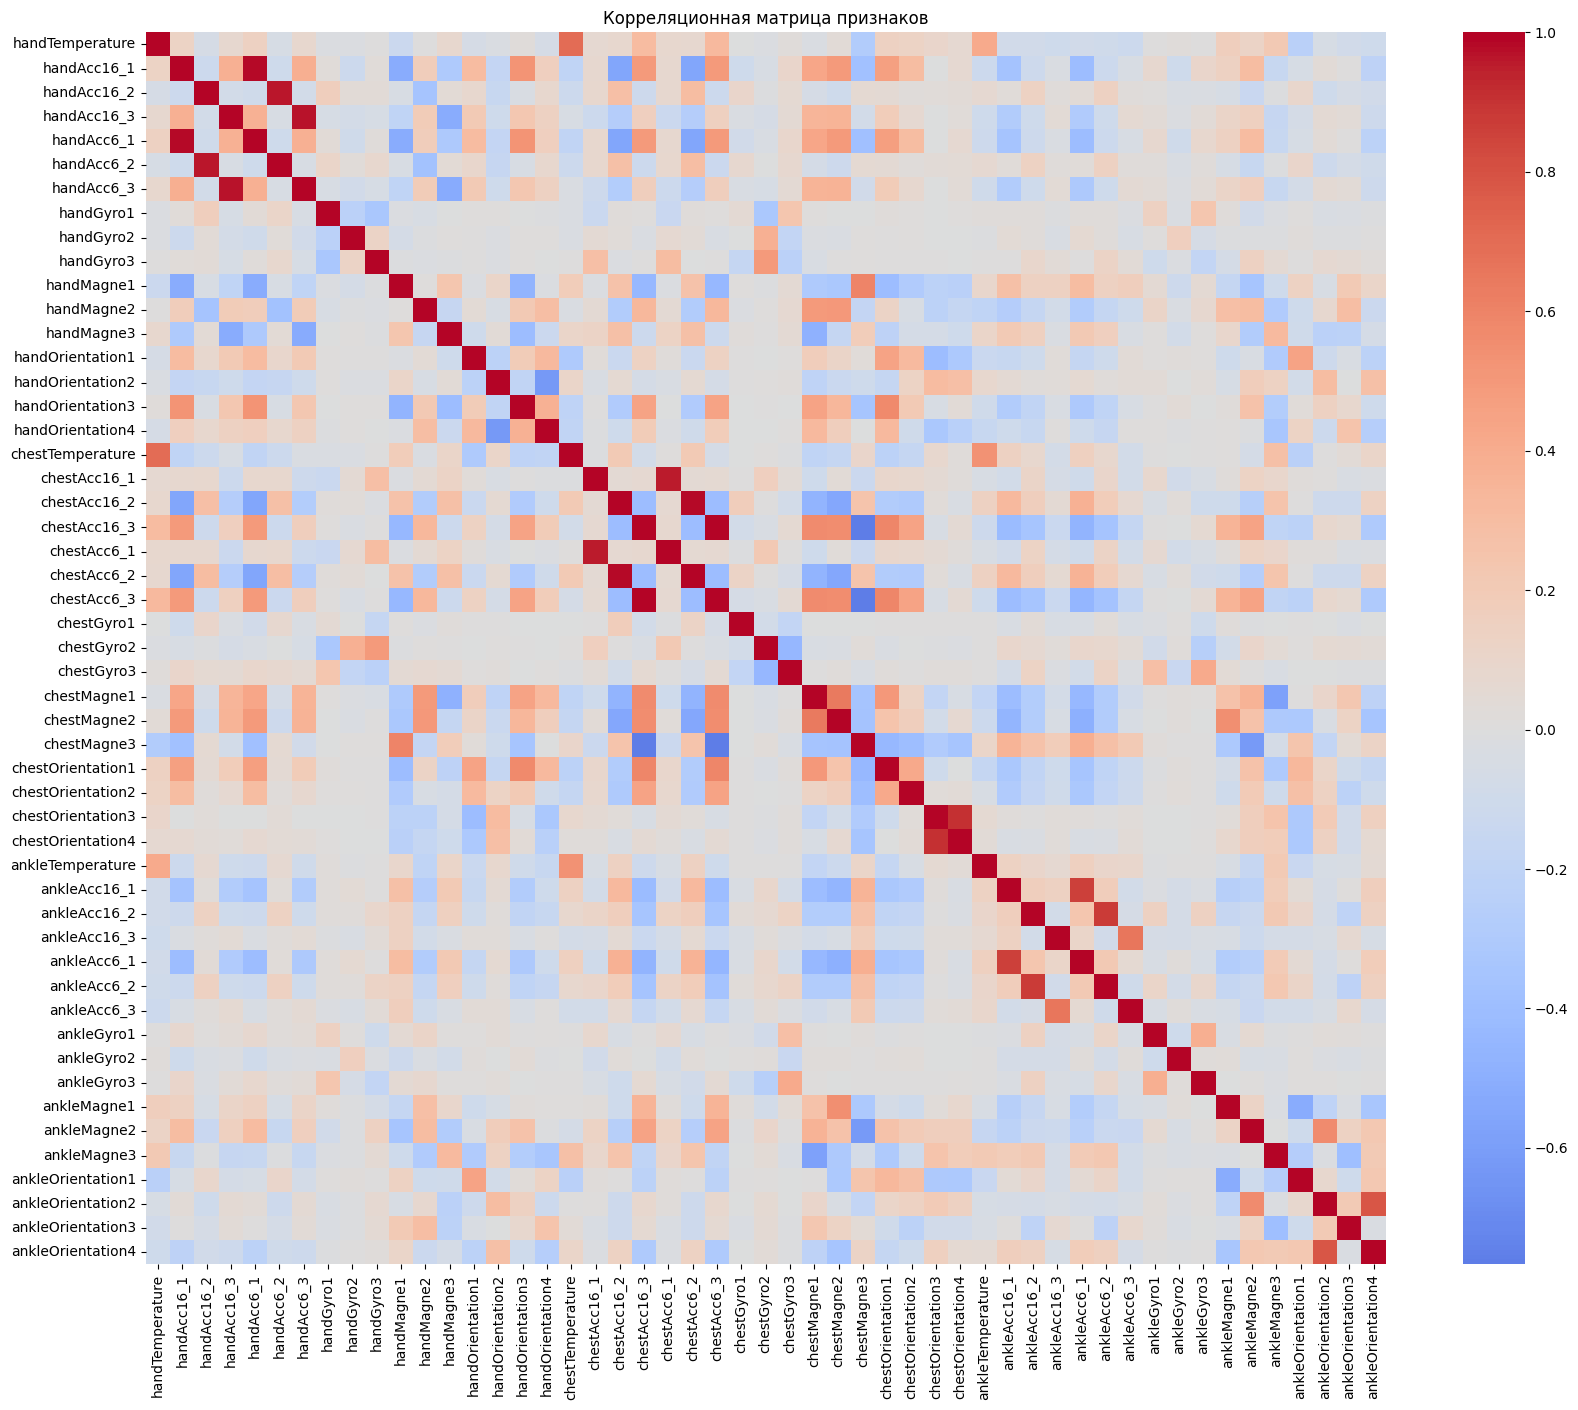

In [52]:
plt.figure(figsize=(20, 16))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Корреляционная матрица признаков')
plt.show()

In [53]:
threshold = 0.95
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"Найдено пар с корреляцией > {threshold}: {len(high_corr_pairs)}")
for pair in high_corr_pairs[:6]:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.4f}")

Найдено пар с корреляцией > 0.95: 6
handAcc16_1 - handAcc6_1: 0.9814
handAcc16_2 - handAcc6_2: 0.9640
handAcc16_3 - handAcc6_3: 0.9721
chestAcc16_1 - chestAcc6_1: 0.9561
chestAcc16_2 - chestAcc6_2: 0.9847
chestAcc16_3 - chestAcc6_3: 0.9910


In [54]:
cols_to_drop = ['handAcc6_1', 'handAcc6_2', 'handAcc6_3',
                'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3']
X_reduced = X.drop(columns=cols_to_drop)
print(f"Признаков после удаления: {X_reduced.shape[1]}")

Признаков после удаления: 45


In [65]:
# ========== 4. АГРЕГАЦИЯ ПО ВРЕМЕННЫМ ОКНАМ (НОВОЕ!) ==========
print("\n" + "="*50)
print("АГРЕГАЦИЯ ПО ВРЕМЕННЫМ ОКНАМ")
print("="*50)

# Создаем временные окна по 50 строк (примерно 5-10 секунд данных)
window_size = 50
n_windows = len(X_reduced) // window_size
print(f"Количество окон: {n_windows}")

# Агрегируем признаки в каждом окне
X_aggregated = []
window_labels = []

for i in range(n_windows):
    start_idx = i * window_size
    end_idx = start_idx + window_size
    window_data = X_reduced.iloc[start_idx:end_idx]

    # Статистики для каждого признака в окне
    window_features = []
    for col in X_reduced.columns:
        window_features.append(window_data[col].mean())      # среднее
        window_features.append(window_data[col].std())       # стандартное отклонение
        window_features.append(window_data[col].max())       # максимум
        window_features.append(window_data[col].min())       # минимум
        window_features.append(window_data[col].max() - window_data[col].min())  # размах

    X_aggregated.append(window_features)

    # Для целей кластеризации берем метку из середины окна (для последующего маппинга)
    window_labels.extend([i] * window_size)

X_aggregated = np.array(X_aggregated)
print(f"Размер агрегированных признаков: {X_aggregated.shape}")


АГРЕГАЦИЯ ПО ВРЕМЕННЫМ ОКНАМ
Количество окон: 10692
Размер агрегированных признаков: (10692, 225)


In [66]:
# ========== 5. УДАЛЕНИЕ МАГНИТОМЕТРОВ (ЗАШУМЛЕНЫ) ==========
# Находим колонки магнитометров в агрегированных данных
# Это сложно, поэтому лучше удалить их до агрегации
print("\nУдаляем магнитометры (шум)...")
magne_cols = [col for col in X_reduced.columns if 'Magne' in col]
X_no_magne = X_reduced.drop(columns=magne_cols)
print(f"Признаков без магнитометров: {X_no_magne.shape[1]}")

# Агрегация без магнитометров
X_aggregated_clean = []
for i in range(n_windows):
    start_idx = i * window_size
    end_idx = start_idx + window_size
    window_data = X_no_magne.iloc[start_idx:end_idx]

    window_features = []
    for col in X_no_magne.columns:
        window_features.append(window_data[col].mean())
        window_features.append(window_data[col].std())
        window_features.append(window_data[col].max())
        window_features.append(window_data[col].min())
        window_features.append(window_data[col].max() - window_data[col].min())

    X_aggregated_clean.append(window_features)

X_aggregated_clean = np.array(X_aggregated_clean)
print(f"Размер агрегированных признаков (без магнитометров): {X_aggregated_clean.shape}")


Удаляем магнитометры (шум)...
Признаков без магнитометров: 36
Размер агрегированных признаков (без магнитометров): (10692, 180)


In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
print("Стандартизация выполнена")

Стандартизация выполнена


In [71]:
# ========== 7. GMM С РАЗНЫМ КОЛИЧЕСТВОМ КЛАСТЕРОВ ==========
print("\n" + "="*50)
print("ОБУЧЕНИЕ GMM МОДЕЛЕЙ")
print("="*50)

best_silhouette = -1
best_model = None
best_k = 0
best_labels_agg = None

for k in [5, 6, 7, 8, 9, 10, 12, 15]:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10, max_iter=300)
    labels_agg = gmm.fit_predict(X_scaled)

    # Silhouette на агрегированных данных
    if len(np.unique(labels_agg)) > 1:
        sil = silhouette_score(X_scaled, labels_agg)
        print(f"GMM k={k}: silhouette = {sil:.4f}")

        if sil > best_silhouette:
            best_silhouette = sil
            best_model = gmm
            best_k = k
            best_labels_agg = labels_agg

print(f"\nЛучшая GMM: k={best_k}, silhouette={best_silhouette:.4f}")


ОБУЧЕНИЕ GMM МОДЕЛЕЙ


KeyboardInterrupt: 

In [ ]:
# ========== 8. ВОССТАНОВЛЕНИЕ МЕТОК ДЛЯ КАЖДОЙ СТРОКИ ==========
# Каждой строке в исходных данных присваиваем метку ее окна
final_labels = []
for i in range(n_windows):
    final_labels.extend([best_labels_agg[i]] * window_size)

# Добавляем последние строки, которые не вошли в полные окна
remaining = len(X_reduced) - len(final_labels)
if remaining > 0:
    final_labels.extend([best_labels_agg[-1]] * remaining)

final_labels = np.array(final_labels)
print(f"Итоговое количество предсказаний: {len(final_labels)}")


In [ ]:
# ========== 9. ОЦЕНКА КАЧЕСТВА ==========
# Сэмплируем для silhouette (так как данных много)
sample_idx = np.random.choice(len(X_scaled), min(30000, len(X_scaled)), replace=False)
final_silhouette = silhouette_score(X_scaled, best_labels_agg, sample_size=30000)
print(f"\nSilhouette на агрегированных данных: {final_silhouette:.4f}")

cluster_counts = pd.Series(final_labels).value_counts().sort_index()
print(f"\nРаспределение по кластерам:")
for i, count in cluster_counts.items():
    print(f"  Кластер {i}: {count} ({count/len(final_labels)*100:.1f}%)")


In [ ]:
# ========== 10. ВИЗУАЛИЗАЦИЯ ==========
# PCA для визуализации кластеров
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled[:min(30000, len(X_scaled))])

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels_agg[:min(30000, len(X_scaled))], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'Визуализация кластеров GMM (k={best_k})')
plt.show()


In [ ]:
# ========== 11. ПОДГОТОВКА ФАЙЛА ДЛЯ KAGGLE ==========
# Преобразование меток в последовательные номера
unique_labels = np.unique(final_labels)
mapping = {old: new+1 for new, old in enumerate(sorted(unique_labels))}
print(f"\nПреобразование меток: {mapping}")

submission = pd.DataFrame({
    'Index': df.index,
    'activityID': final_labels
})
submission['activityID'] = submission['activityID'].map(mapping)

submission.to_csv('submission_gmm_window.csv', index=False)
print(f"\nФайл submission_gmm_window.csv сохранен с {len(submission)} строками")
print(f"Первые 10 строк:")
print(submission.head(10))
print(f"\nРаспределение после преобразования:")
print(submission['activityID'].value_counts().sort_index())


In [ ]:
# ========== 12. ЭКСПЕРИМЕНТЫ С ДРУГИМИ ПАРАМЕТРАМИ ==========
print("\n" + "="*50)
print("ЭКСПЕРИМЕНТЫ С РАЗНЫМИ ПАРАМЕТРАМИ")
print("="*50)

# Пробуем разные размеры окон
for window_size_test in [30, 50, 100]:
    print(f"\nРазмер окна: {window_size_test}")
    n_windows_test = len(X_no_magne) // window_size_test

    X_agg_test = []
    for i in range(n_windows_test):
        start_idx = i * window_size_test
        end_idx = start_idx + window_size_test
        window_data = X_no_magne.iloc[start_idx:end_idx]

        window_features = []
        for col in X_no_magne.columns:
            window_features.append(window_data[col].mean())
            window_features.append(window_data[col].std())

        X_agg_test.append(window_features)

    X_agg_test = np.array(X_agg_test)
    scaler_test = StandardScaler()
    X_scaled_test = scaler_test.fit_transform(X_agg_test)

    gmm_test = GaussianMixture(n_components=best_k, random_state=42, n_init=10)
    labels_test = gmm_test.fit_predict(X_scaled_test)

    if len(np.unique(labels_test)) > 1:
        sil_test = silhouette_score(X_scaled_test, labels_test)
        print(f"  Silhouette: {sil_test:.4f}")

        # Восстанавливаем метки
        final_labels_test = []
        for i in range(n_windows_test):
            final_labels_test.extend([labels_test[i]] * window_size_test)
        remaining_test = len(X_no_magne) - len(final_labels_test)
        if remaining_test > 0:
            final_labels_test.extend([labels_test[-1]] * remaining_test)

        # Сохраняем файл
        unique_test = np.unique(final_labels_test)
        mapping_test = {old: new+1 for new, old in enumerate(sorted(unique_test))}
        sub_test = pd.DataFrame({'Index': df.index, 'activityID': final_labels_test})
        sub_test['activityID'] = sub_test['activityID'].map(mapping_test)
        sub_test.to_csv(f'submission_window_{window_size_test}_k{best_k}.csv', index=False)
        print(f"  Сохранен: submission_window_{window_size_test}_k{best_k}.csv")

print("\n" + "="*50)
print("ГОТОВО! Файлы для отправки на Kaggle:")
print("- submission_gmm_window.csv (основной)")
print("- submission_window_30_k{best_k}.csv")
print("- submission_window_50_k{best_k}.csv")
print("- submission_window_100_k{best_k}.csv")
print("="*50)